## Import Lib

In [47]:
import pandas as pd
import numpy as np

import scipy.cluster.hierarchy as sch

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

import matplotlib.pyplot as plt

from pickle import dump

## Data Collection

In [3]:
college_data=pd.read_csv("college_list.csv")

## Data Preprocessing / Data cleaaning

In [4]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [5]:
college_data.dtypes

College_Name              object
Student_Faculty_Ratio      int64
Annual_Fees_INR            int64
Placement_Percentage       int64
Average_Package_LPA      float64
Infrastructure_Score       int64
dtype: object

## Data Preparation

In [6]:
X = college_data.drop("College_Name",axis=1)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


## Use Standard Scalar in distance based metric because in clustering we distance based metric.why?
- must use StandardScaler (or MinMaxScaler) before running Hierarchical Clustering.

- The precise reason: Scaling ensures that every feature contributes equally to the distance metric, preventing columns with large magnitudes from drowning out columns with smaller magnitudes.

- If you calculate the Euclidean distance between two colleges without scaling, a difference of 10,000 INR in fees will completely overwhelm a difference of 5 LPA in package. The algorithm will basically cluster colleges only by their fees and completely ignore the package, student-faculty ratio, and infrastructure scores.

In [7]:
std_scalar = StandardScaler()
scaled_X=pd.DataFrame(std_scalar.fit_transform(X))
scaled_X

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


## Visualization using dendogram on how datapoints are form clusters

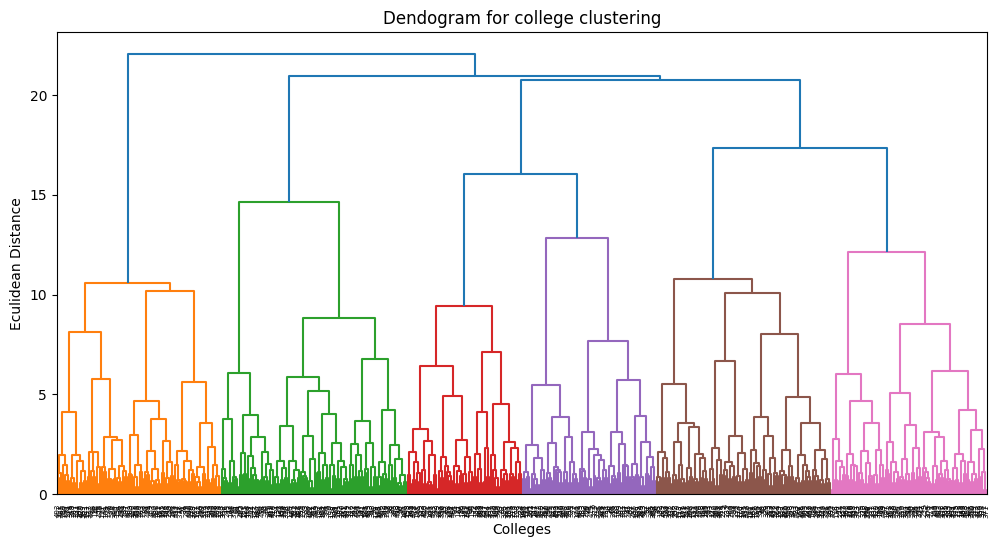

In [8]:
plt.figure(figsize=(12,6))
sch.dendrogram(sch.linkage(scaled_X,method='ward'))
plt.xlabel("Colleges")
plt.ylabel("Eculidean Distance")
plt.title("Dendogram for college clustering")
plt.show()

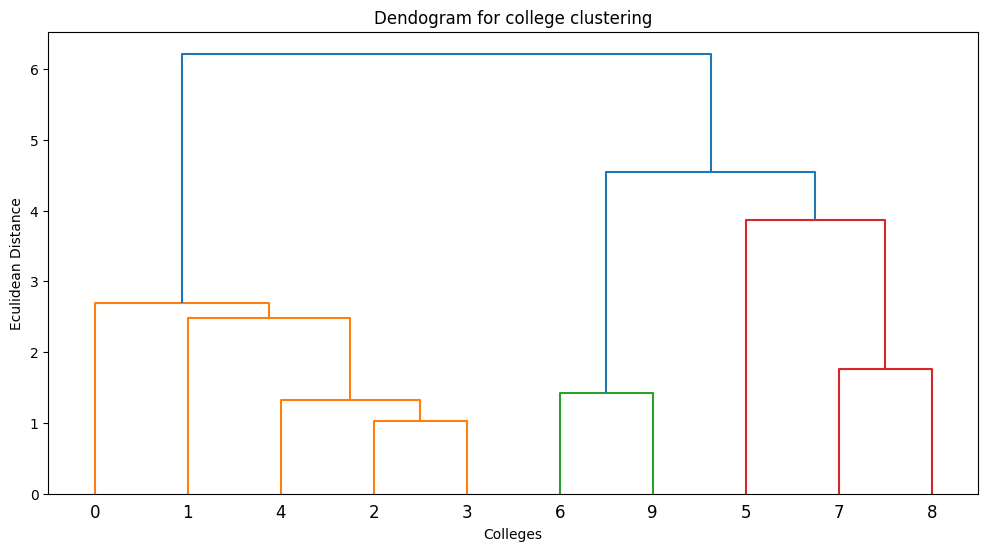

In [9]:
plt.figure(figsize=(12,6))
sch.dendrogram(sch.linkage(scaled_X.head(10),method='ward'))
plt.xlabel("Colleges")
plt.ylabel("Eculidean Distance")
plt.title("Dendogram for college clustering")
plt.show()

In [10]:

agglomerative_clust = AgglomerativeClustering(n_clusters=3,metric="euclidean",linkage='ward')
agglomerative_clust.fit(scaled_X)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [11]:
y_output = agglomerative_clust.fit_predict(scaled_X)

In [12]:
college_data["College_Level"] = y_output

In [13]:
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
...,...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3,1
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


In [14]:
college_data[college_data["College_Level"]==0]

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
5,Government College of Technology Coimbatore - ...,28,226582,45,9.32,4,0
...,...,...,...,...,...,...,...
494,Kumaraguru College of Technology - Campus 17,11,34324,73,11.40,3,0
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


In [15]:
X["College_Level"]=y_output

In [17]:
X.groupby(by ="College_Level").agg(['mean'])

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
,mean,mean,mean,mean,mean
College_Level,,,,,
0,20.407051,121853.471154,67.278846,6.954583,6.509615
1,17.159091,156795.136364,85.568182,5.565682,3.965909
2,11.650000,175656.000000,59.790000,8.362500,6.080000


In [18]:
X.groupby(by ="College_Level").agg(['min','max'])

Student_Faculty_Ratio     Annual_Fees_INR          \
                                min max             min     max   
College_Level                                                     
0                                 8  29           30404  249536   
1                                 8  29           39337  248803   
2                                 8  20           49065  249930   

              Placement_Percentage     Average_Package_LPA         \
                               min max                 min    max   
College_Level                                                       
0                               40  99                2.00  11.99   
1                               64  99                2.09  11.96   
2                               40  99                2.01  11.91   

              Infrastructure_Score      
                               min max  
College_Level                           
0                                3   9  
1                                3   9  
2                                3   9

## Based on the placement mean we r going to classify the output 0 as mid level, 1 as best, 2 as Lower level

In [34]:
clusters = {
    1:"Best",
    2:"Lower",
    0:"Medium"
}

college_data["College_category"] = X["College_Level"].map(clusters)
X["College_category"] = X["College_Level"].map(clusters)

In [35]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
College_Level            0
College_category         0
dtype: int64

## Now performing supervised learning 

In [36]:
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level,College_category
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2,Lower
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0,Medium
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0,Medium
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0,Medium
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0,Medium
...,...,...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0,Medium
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0,Medium
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3,1,Best
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0,Medium


In [38]:

output_y = X["College_category"]


In [63]:
X_train, X_test, y_train, y_test = train_test_split(scaled_X,output_y,test_size=0.20,shuffle=True,random_state=42,stratify=output_y)

In [43]:
X_train.shape

(400, 5)

In [44]:
X_test.shape

(100, 5)

In [45]:
output_y.shape

(500,)

In [65]:
randomforest_model = RandomForestClassifier(max_depth=4,class_weight='balanced')
randomforest_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred_train = randomforest_model.predict(X_train)
y_pred_test = randomforest_model.predict(X_test)


In [67]:
print(classification_report(y_test,y_pred_test))
print(confusion_matrix(y_test,y_pred_test))

              precision    recall  f1-score   support

        Best       0.82      0.78      0.80        18
       Lower       0.79      0.95      0.86        20
      Medium       0.93      0.89      0.91        62

    accuracy                           0.88       100
   macro avg       0.85      0.87      0.86       100
weighted avg       0.88      0.88      0.88       100

[[14  1  3]
 [ 0 19  1]
 [ 3  4 55]]


In [68]:
print(classification_report(y_train,y_pred_train))
print(confusion_matrix(y_train,y_pred_train))

              precision    recall  f1-score   support

        Best       0.91      0.97      0.94        70
       Lower       0.87      0.97      0.92        80
      Medium       0.99      0.93      0.96       250

    accuracy                           0.94       400
   macro avg       0.92      0.96      0.94       400
weighted avg       0.95      0.94      0.95       400

[[ 68   0   2]
 [  1  78   1]
 [  6  12 232]]


## deployment

In [70]:
dump(randomforest_model,open("College_level_predict.pkl","wb"))